#### Loading packages

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#### Setting root directory path

Your path is of course different.

In [3]:
ROOT = r'C:\Users\PC_DS_ECON_5\Desktop\data-analytics-python' 


#### Loading data

Let us load the hotels-europe dataset using the `pd.read_csv()` function and bind the name `hotels_europe_df` to the resulting data frame (put differently: assign the imported data frame to the variable `hotels_europe_df`).

In [4]:
hotels_europe_df = pd.read_csv(ROOT + '/data/hotels_europe.csv')

In [5]:
hotels_europe_df = hotels_europe_df.drop(columns=['Unnamed: 0'])

Let us keep only the columns that correspond to actual variables.

In [6]:
columns_to_keep = ['hotel_id', 'city', 'distance', 'stars', 'rating', 'country', 
                   'accommodation_type', 'price', 'weekend', 'holiday', 'nnights', 
                   'yearmonth', 'nb_months_observed']
hotels_europe_df = hotels_europe_df.loc[:, columns_to_keep]

#### Pandas data types

Let us make sure that the variables are all in pandas data types by running the following code using the `convert_dtypes()` method.

In [7]:
hotels_europe_df = hotels_europe_df.convert_dtypes()

Let us list the data types for all variables by running the following code.

In [8]:
hotels_europe_df.dtypes

hotel_id                Int64
city                   string
distance              Float64
stars                 Float64
rating                Float64
country                string
accommodation_type     string
price                   Int64
weekend                 Int64
holiday                 Int64
nnights                 Int64
yearmonth              string
nb_months_observed      Int64
dtype: object

Let us make sure the `yearmonth` variable's type is `datetime`.

In [9]:
hotels_europe_df['yearmonth'] = pd.to_datetime(hotels_europe_df['yearmonth'])

In [10]:
hotels_europe_df.dtypes

hotel_id                       Int64
city                          string
distance                     Float64
stars                        Float64
rating                       Float64
country                       string
accommodation_type            string
price                          Int64
weekend                        Int64
holiday                        Int64
nnights                        Int64
yearmonth             datetime64[us]
nb_months_observed             Int64
dtype: object

Let us update some city names with `.loc[]`: Kiev --> Kyiv, Tallin --> Tallinn, Valetta --> Valletta 

In [11]:
hotels_europe_df.loc[hotels_europe_df['city'] == 'Kiev', 'city'] = 'Kyiv'
hotels_europe_df.loc[hotels_europe_df['city'] == 'Tallin', 'city'] = 'Tallinn'
hotels_europe_df.loc[hotels_europe_df['city'] == 'Valetta', 'city'] = 'Valletta'

Let us create a new variable `price_per_night` which is equal to the price divided by the number of nights.

In [12]:
hotels_europe_df['price_per_night'] = hotels_europe_df['price'] / hotels_europe_df['nnights']

Let us aggregate the dataset at the `hotel_id`-`yearmonth` level, i.e. to have as unit of observation `[hotel_id, yearmonth]`.

In [13]:
# Aggregate the price per night at the level hotel_id X yearmonth
# To have only one price per hotel_id X yearmonth pair
# Take the mean price per hotel_id X yearmonth pair
# .groupby() , .agg()
# creating the intermediate dataframe 
# --> identifiers, mean prices per identifier combination 
df = (
    hotels_europe_df
        .groupby(by=['hotel_id', 'yearmonth'])
        .agg({'price_per_night': 'mean'})
        .reset_index()
        .copy()
)
# merge the intermediate dataframe with the original
hotels_europe_df = pd.merge(left=hotels_europe_df.drop(columns=['price_per_night']),
                            right=df,
                            on=['hotel_id', 'yearmonth'],
                            how='left')
# checking the dimensions 
# --> dimensions of new dataframe = dimensions of original
print(hotels_europe_df.shape)

# dropping some columns --> 'nnights', 'weekend', 'price'
# then dropping duplicates
hotels_europe_df = (
    hotels_europe_df
        .drop(columns=['nnights', 'weekend', 'price'])
        .drop_duplicates()
)

(148021, 14)


In [14]:
# checking that the unit of observation is hotel_id X yearmonth 
hotels_europe_df[['hotel_id', 'yearmonth']].value_counts().value_counts()

count
1    122776
Name: count, dtype: int64

#### Some exploratory exercises

What is the least common type of accommodation (excluding `All inclusive`) in the dataset?

In [15]:
df = hotels_europe_df.copy()
(
    df
        .value_counts(subset=['accommodation_type'], ascending=True)
        .reset_index()
        .head(10)
)


,accommodation_type,count
0,All inclusive,5
1,Castle,5
2,Chalet,9
3,Cottage,10
4,Cabin / Lodge,11
5,Motel,19
6,Pousada,23
7,House boat,26
8,Resort,46
9,Caravan Park,47


How many cities are there in the dataset?

In [16]:
# Your code goes here

How many cities are there with at least 1000 observations?

In [17]:
# Your code goes here

There are two inconsistent `city`-`country` pairs. Let us find them by printing all unique `city`-`country` pairs.

In [18]:
df = hotels_europe_df.copy()
df = (
    df[['city', 'country']] # selecting columns city, country
        .drop_duplicates() # keeping unique combinations of city-country
        .value_counts(subset=['city']) # counting the number of city-country pairs for each city      
        .reset_index() # formatting
)

df = df.loc[df['count'] > 1, ['city']]
df


,city
0,Bucharest
1,Lisbon


Let us assume that in these two cases the city is correct and the country is wrong. Let us assign the correct country using `.loc[]`.

In [19]:
df = hotels_europe_df.copy()
# for observations with city=Bucharest, set the country to Romania
df.loc[df['city'] == 'Bucharest', 'country'] = 'Romania'
df.loc[df['city'] == 'Lisbon', 'country'] = 'Portugal'
hotels_europe_df = df

How many observations are there for which the `accommodation_type` is missing but the `price_per_night` is not missing? The relevant methods are called `.isna()` and `.notna()`.

In [20]:
df = hotels_europe_df.copy()
(
    df
        .loc[df['accommodation_type'].isna() 
             & df['price_per_night'].notna(), :]
        .shape # number of rows and columns
)



(54, 11)

In which city can be found the lowest price per night for an `accommodation_type='Guest House'` with a rating of at least 4 in Germany?

In [21]:
# Your code goes here

#### Some transformations

Let us convert the `stars` variable to an ordered categorical variable using `pd.Categorical()`.

In [22]:
# Your code goes here


Let us produce a histogram of the `stars` variable.

In [23]:
# Your code goes here

Let us reduce the number of categories of the `stars` variable to have only five categories: `[1,2,3,4,5]`. Let us round decimals downwards with `np.floor` from `numpy`.

In [24]:
# Your code goes here

Let us convert the `distance` to an interval categorical variable using `pd.cut`. Let the bins be set to `[0, 1, 2, 3, 5, 10, 20, 50]`.

In [25]:
df = hotels_europe_df.copy()
df['distance']

0         3.1
2         3.1
4         3.1
5         3.1
6         0.9
         ... 
148015    1.1
148017    1.1
148018    1.1
148019    1.1
148020    1.1
Name: distance, Length: 122776, dtype: Float64

In [26]:
df = hotels_europe_df.copy()
df['distance'] = pd.cut(df['distance'], bins=[0, 1, 2, 3, 5, 10, 20, 50])
df['distance']
hotels_europe_df = df.copy()

#### Plotting conditional average prices against `distance`, `stars`, and `yearmonth`

A combination of the `.groupby()` method as well as the `.agg()` or the `.mean()` methods can be used to obtain conditional means.

Let us restrict our attention to accommodation types for which there are at least 1000 observations in the dataset.

In [27]:
# Your code goes here

Now: Let us compute and plot the average `price_per_night` by `distance` for hotels with at least three stars for the three German cities (Berlin, Hamburg, Munich) separately.

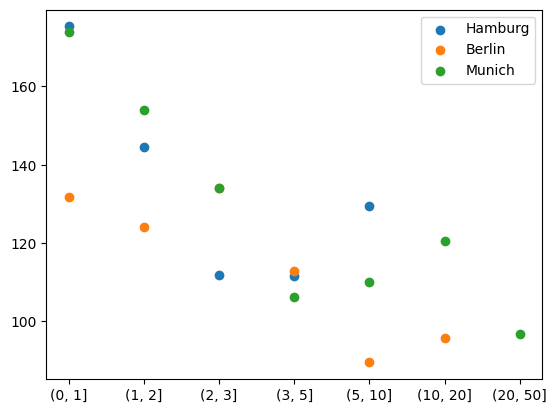

In [28]:
df = hotels_europe_df.copy()
df = (
    df
        .loc[df['stars'] >= 3, :] # selecting hotels with at least three stars
        .groupby(['distance', 'city']) # grouping by distance and city
        .agg({'price_per_night': 'mean'}) # mean price by city-distance pair
        .reset_index() # formatting
)

fig, ax = plt.subplots()
subdf = df.loc[df['city'] == 'Hamburg',:]
subdf.sort_values(by='distance')
ax.scatter(
    # interval datatype (for distance) does not work for scatter, 
    # let us use a string instead
    x=subdf['distance'].astype('string'),     
    y=subdf['price_per_night'],
    label='Hamburg'
)

subdf = df.loc[df['city'] == 'Berlin',:]
subdf.sort_values(by='distance')

ax.scatter(
    # interval datatype (for distance) does not work for scatter, 
    # let us use a string instead
    x=subdf['distance'].astype('string'),     
    y=subdf['price_per_night'],
    label='Berlin'
)

subdf = df.loc[df['city'] == 'Munich',:]
subdf.sort_values(by='distance')

ax.scatter(
    # interval datatype (for distance) does not work for scatter, 
    # let us use a string instead
    x=subdf['distance'].astype('string'),     
    y=subdf['price_per_night'],
    label='Munich'
)

ax.legend()


Let us plot the distribution of observations by `distance` for hotels with at least three stars for the three German cities (Berlin, Hamburg, Munich) separately.

In [29]:
# Your code goes here

Let us compute and plot the average `price_per_night` by `yearmonth` for hotels with at least three stars for the three French cities (Lyon, Marseille, Paris) separately.

In [30]:
# Your code goes here

Let us compute and plot the average `price_per_night` by `stars` for the three UK cities (Birmingham, Glasgow, London) separately.

In [31]:
# Your code goes here